# Эксперимент по масштабируемости Spark

Задача ТЗ: *"Провести эксперимент по масштабируемости. Насколько увеличится время выполнения при увеличении количества данных. Зависимость должна быть близка к линейной."*

**Честная методика:**
1. Данные создаются прямо в Spark через `range(...)`, без промежуточных файлов и без HDFS-записи.
2. Для каждой точки выполняется один warm-up прогон.
3. Основной замер повторяется несколько раз в случайном порядке.
4. В отчёт идут медиана, минимум, максимум и стандартное отклонение.
5. На графике показываются и сырые точки, и агрегированная линия.

По умолчанию ноутбук работает в локальном режиме и не требует `winutils.exe`.
Если задать `SCALING_SPARK_MASTER`, он переключится на кластерный Spark.


In [1]:
import os
import time
import random

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import rand, lit, when, col, floor, sum as ssum, avg, expr

try:
    from IPython.display import display
except Exception:  # pragma: no cover
    def display(obj):
        print(obj)


def _parse_int_list(value: str) -> list[int]:
    return [int(item) for item in value.split(",") if item.strip()]


SCALING_SPARK_MASTER = os.environ.get("SCALING_SPARK_MASTER", "").strip() or None
SCALING_SIZES_RAW = os.environ.get("SCALING_SIZES")
SCALING_EXECUTORS_RAW = os.environ.get("SCALING_EXECUTORS", "1,2")
REPEATS = int(os.environ.get("SCALING_REPEATS", "3"))
WARMUP = int(os.environ.get("SCALING_WARMUP", "1"))

if SCALING_SIZES_RAW:
    SIZES = _parse_int_list(SCALING_SIZES_RAW)
elif SCALING_SPARK_MASTER:
    SIZES = [1_000_000, 5_000_000, 20_000_000, 50_000_000]
else:
    SIZES = [100_000, 250_000, 500_000, 1_000_000]

EXECUTOR_COUNTS = _parse_int_list(SCALING_EXECUTORS_RAW)
EXECUTOR_LABEL = "executors" if SCALING_SPARK_MASTER else "local threads"


def make_session(app_name: str, workers: int) -> SparkSession:
    builder = (
        SparkSession.builder
        .appName(app_name)
        .config("spark.ui.enabled", "false")
        .config("spark.sql.shuffle.partitions", str(max(4, workers * 4)))
        .config("spark.sql.adaptive.enabled", "false")
    )
    if SCALING_SPARK_MASTER:
        builder = (
            builder.master(SCALING_SPARK_MASTER)
            .config("spark.executor.instances", str(workers))
            .config("spark.executor.cores", "2")
            .config("spark.executor.memory", "1500m")
        )
    else:
        builder = builder.master(f"local[{workers}]")
    return builder.getOrCreate()


def build_detections_df(spark: SparkSession, num_rows: int) -> pd.DataFrame:
    classes = ["vessel", "ice_field", "broken_ice", "slush_ice"]
    class_literal = ",".join([repr(c) for c in classes])
    partitions = max(4, min(16, max(1, num_rows // 50_000)))
    return (
        spark.range(0, num_rows, 1, partitions)
        .withColumn("cam_id", when(col("id") % 2 == 0, "cam_a").otherwise("cam_b"))
        .withColumn("class_idx", floor(rand(seed=42 + num_rows) * len(classes)).cast("int"))
        .withColumn("class_name", expr(f"element_at(array({class_literal}), class_idx + 1)"))
        .withColumn("confidence", rand(seed=123 + num_rows) * 0.6 + 0.4)
        .withColumn("area_pixels", floor(rand(seed=456 + num_rows) * 50000 + 100).cast("int"))
        .withColumn("ice_conc", rand(seed=789 + num_rows))
        .withColumn("ice_severity", rand(seed=101112 + num_rows))
        .withColumn("dt", lit("2026-04-18"))
        .drop("id", "class_idx")
    )


def run_query(df):
    result = (
        df.groupBy("cam_id", "class_name")
        .agg(
            ssum("area_pixels").alias("sum_area_pixels"),
            avg("confidence").alias("avg_confidence"),
            avg("ice_conc").alias("avg_ice_conc"),
        )
    )
    rows = result.collect()
    return len(rows)


def benchmark_executor_count(num_workers: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    spark = make_session(f"scaling-{num_workers}", num_workers)
    trials = []
    try:
        if WARMUP:
            warmup_df = build_detections_df(spark, min(SIZES))
            _ = run_query(warmup_df)
            spark.catalog.clearCache()

        schedule = [(size, rep) for size in SIZES for rep in range(REPEATS)]
        random.Random(42 + num_workers).shuffle(schedule)

        for size, rep in schedule:
            spark.catalog.clearCache()
            df = build_detections_df(spark, size)
            t0 = time.perf_counter()
            result_rows = run_query(df)
            elapsed = time.perf_counter() - t0
            trials.append(
                {
                    "rows": size,
                    "executors": num_workers,
                    "trial": rep + 1,
                    "time_s": elapsed,
                    "result_rows": result_rows,
                }
            )
            print(
                f"workers={num_workers} rows={size:>10,} trial={rep + 1} "
                f"time={elapsed:.2f}s result_rows={result_rows}"
            )

        trial_df = pd.DataFrame(trials).sort_values(["rows", "trial"]).reset_index(drop=True)
        summary_df = (
            trial_df.groupby(["rows", "executors"], as_index=False)
            .agg(
                runs=("time_s", "count"),
                time_median_s=("time_s", "median"),
                time_mean_s=("time_s", "mean"),
                time_std_s=("time_s", "std"),
                time_min_s=("time_s", "min"),
                time_max_s=("time_s", "max"),
            )
            .sort_values("rows")
            .reset_index(drop=True)
        )
        summary_df["time_std_s"] = summary_df["time_std_s"].fillna(0.0)
        return trial_df, summary_df
    finally:
        spark.stop()


def linear_r2(x: np.ndarray, y: np.ndarray) -> float:
    coeffs = np.polyfit(x, y, 1)
    predicted = np.polyval(coeffs, x)
    ss_res = float(np.sum((y - predicted) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    return 1.0 if ss_tot == 0 else 1 - ss_res / ss_tot


## Шаг 1. Генерация синтетических данных

Здесь данные не пишутся на диск. Spark сам создаёт строки по диапазону `range(...)`,
а затем добавляет признаки, похожие на реальные детекции.
Такой вариант честнее для измерения вычислительной нагрузки и не упирается в Hadoop-файловую систему на Windows.


In [2]:
spark = make_session("scaling-smoke", max(EXECUTOR_COUNTS))
print(f"Mode: {'cluster' if SCALING_SPARK_MASTER else 'local'}")
print(f"Worker counts: {EXECUTOR_COUNTS}")
print(f"Sizes: {SIZES}")

sample_df = build_detections_df(spark, min(SIZES))
sample_df.show(5, truncate=False)

spark.stop()


Mode: local
Worker counts: [1, 2]
Sizes: [100000, 250000, 500000, 1000000]
+------+----------+------------------+-----------+-------------------+-------------------+----------+
|cam_id|class_name|confidence        |area_pixels|ice_conc           |ice_severity       |dt        |
+------+----------+------------------+-----------+-------------------+-------------------+----------+
|cam_a |ice_field |0.9571949464124964|22237      |0.5076624917011355 |0.48892602981564925|2026-04-18|
|cam_b |slush_ice |0.6689397018277088|3598       |0.21074134532697653|0.7994399368069937 |2026-04-18|
|cam_a |ice_field |0.8674831913669699|49762      |0.5616515306670379 |0.2569724046631737 |2026-04-18|
|cam_b |vessel    |0.4586583643042641|1280       |0.7487144806791021 |0.8298966319943428 |2026-04-18|
|cam_a |slush_ice |0.4357431060247494|30818      |0.3219040264701962 |0.3057304559226709 |2026-04-18|
+------+----------+------------------+-----------+-------------------+-------------------+----------+
only sh

## Шаг 2. Функция замера времени

Замеряем одну и ту же агрегацию для всех объёмов:

- группировка по `cam_id` и `class_name`;
- сумма площади объектов;
- средняя уверенность;
- средняя доля льда.

Важно: в этом эксперименте измеряется вся Spark-вычислительная цепочка на синтетических данных,
а не скорость записи Parquet в HDFS. Это позволяет запускать тест и на Windows, и на кластере.


In [3]:
print("Benchmark settings:")
print(f"  mode:     {'cluster' if SCALING_SPARK_MASTER else 'local'}")
print(f"  workers:  {EXECUTOR_COUNTS}")
print(f"  repeats:  {REPEATS}")
print(f"  warm-up:  {WARMUP}")

all_trials = []
summary_parts = []

for num_workers in EXECUTOR_COUNTS:
    trial_df, summary_df = benchmark_executor_count(num_workers)
    all_trials.append(trial_df)
    summary_parts.append(summary_df)

trial_df = pd.concat(all_trials, ignore_index=True).sort_values(["executors", "rows", "trial"]).reset_index(drop=True)
summary_df = pd.concat(summary_parts, ignore_index=True).sort_values(["executors", "rows"]).reset_index(drop=True)

display(trial_df)
display(summary_df)


Benchmark settings:
  mode:     local
  workers:  [1, 2]
  repeats:  3
  warm-up:  1
workers=1 rows= 1,000,000 trial=2 time=1.44s result_rows=8
workers=1 rows=   100,000 trial=2 time=0.57s result_rows=8
workers=1 rows= 1,000,000 trial=1 time=1.47s result_rows=8
workers=1 rows=   250,000 trial=1 time=0.66s result_rows=8
workers=1 rows= 1,000,000 trial=3 time=0.76s result_rows=8
workers=1 rows=   500,000 trial=1 time=0.71s result_rows=8
workers=1 rows=   500,000 trial=3 time=0.58s result_rows=8
workers=1 rows=   250,000 trial=3 time=0.49s result_rows=8
workers=1 rows=   500,000 trial=2 time=0.44s result_rows=8
workers=1 rows=   100,000 trial=3 time=0.19s result_rows=8
workers=1 rows=   250,000 trial=2 time=0.38s result_rows=8
workers=1 rows=   100,000 trial=1 time=0.34s result_rows=8
workers=2 rows=   250,000 trial=3 time=0.46s result_rows=8
workers=2 rows=   250,000 trial=2 time=0.34s result_rows=8
workers=2 rows= 1,000,000 trial=3 time=0.60s result_rows=8
workers=2 rows=   100,000 tria

,rows,executors,trial,time_s,result_rows
0,100000,1,1,0.338936,8
1,100000,1,2,0.571132,8
2,100000,1,3,0.192086,8
3,250000,1,1,0.659003,8
4,250000,1,2,0.383825,8
5,250000,1,3,0.491122,8
6,500000,1,1,0.712001,8
7,500000,1,2,0.439975,8
8,500000,1,3,0.580761,8
9,1000000,1,1,1.467335,8


,rows,executors,runs,time_median_s,time_mean_s,time_std_s,time_min_s,time_max_s
0,100000,1,3,0.338936,0.367385,0.191118,0.192086,0.571132
1,250000,1,3,0.491122,0.511317,0.138696,0.383825,0.659003
2,500000,1,3,0.580761,0.577579,0.136041,0.439975,0.712001
3,1000000,1,3,1.438394,1.223037,0.398336,0.763381,1.467335
4,100000,2,3,0.362736,0.363806,0.025414,0.338944,0.389738
5,250000,2,3,0.337544,0.368304,0.079570,0.308705,0.458663
6,500000,2,3,0.539648,0.528630,0.040660,0.483597,0.562645
7,1000000,2,3,0.600714,0.548920,0.100847,0.432699,0.613345


## Шаг 3. Графики

На графиках показаны сырые точки и медианные значения с диапазоном от минимума до максимума.
Если где-то ускорение не выросло, это тоже результат: он показывает накладные расходы Spark и сетевые/планировочные эффекты.


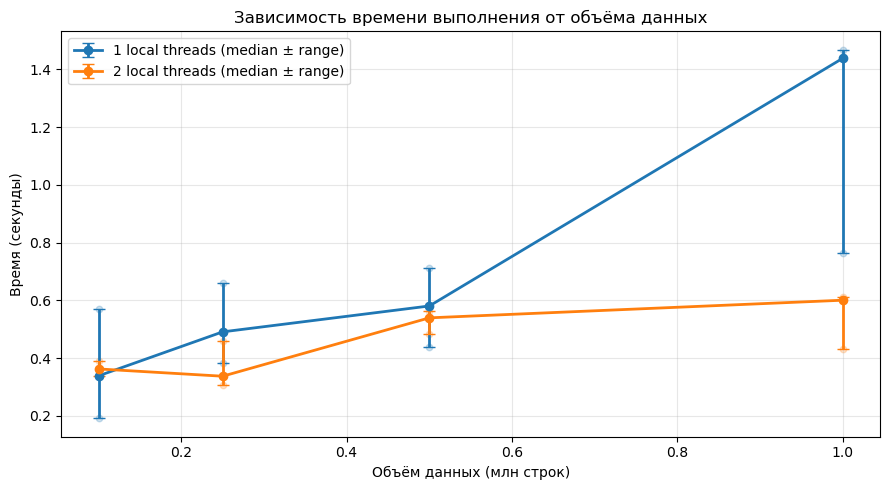

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for num_workers in EXECUTOR_COUNTS:
    sub_summary = summary_df[summary_df.executors == num_workers].sort_values("rows")
    sub_trials = trial_df[trial_df.executors == num_workers]
    ax.scatter(sub_trials.rows / 1e6, sub_trials.time_s, alpha=0.22, s=22)
    ax.errorbar(
        sub_summary.rows / 1e6,
        sub_summary.time_median_s,
        yerr=[
            sub_summary.time_median_s - sub_summary.time_min_s,
            sub_summary.time_max_s - sub_summary.time_median_s,
        ],
        marker="o",
        capsize=4,
        linewidth=2,
        label=f"{num_workers} {EXECUTOR_LABEL} (median ± range)",
    )
ax.set_xlabel("Объём данных (млн строк)")
ax.set_ylabel("Время (секунды)")
ax.set_title("Зависимость времени выполнения от объёма данных")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("scaling_time_vs_rows.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.1 Ускорение и линейность

Speedup считаем по медианным временам: `baseline / current`.
Если speedup меньше 1, это не ошибка, а честный результат: дополнительные ресурсы не окупили накладные расходы.


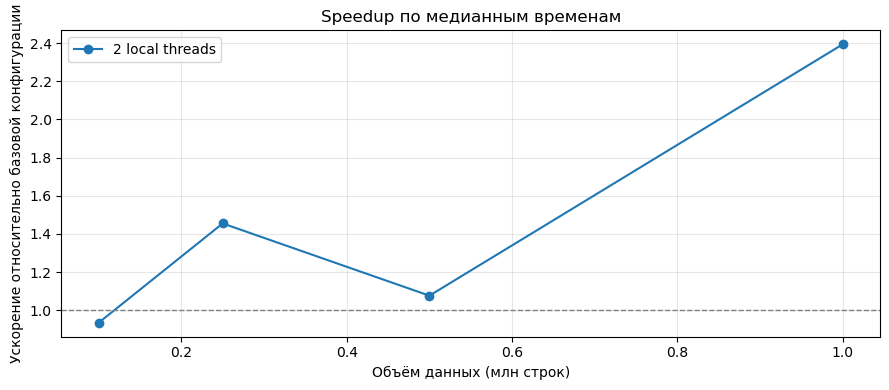

Linear fit quality by executors:
  1 local threads: R^2 = 0.9419
  2 local threads: R^2 = 0.8285


In [5]:
pivot = summary_df.pivot(index="rows", columns="executors", values="time_median_s").sort_index()
baseline_exec = EXECUTOR_COUNTS[0]
baseline = pivot[baseline_exec]

speedup = pd.DataFrame(index=pivot.index)
for num_workers in EXECUTOR_COUNTS[1:]:
    speedup[num_workers] = baseline / pivot[num_workers]

fig, ax = plt.subplots(figsize=(9, 4))
for num_workers in EXECUTOR_COUNTS[1:]:
    ax.plot(speedup.index / 1e6, speedup[num_workers], marker="o", label=f"{num_workers} {EXECUTOR_LABEL}")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Объём данных (млн строк)")
ax.set_ylabel("Ускорение относительно базовой конфигурации")
ax.set_title("Speedup по медианным временам")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("scaling_speedup.png", dpi=150, bbox_inches="tight")
plt.show()

print("Linear fit quality by executors:")
for num_workers in EXECUTOR_COUNTS:
    sub = summary_df[summary_df.executors == num_workers].sort_values("rows")
    r2 = linear_r2(sub.rows.to_numpy(dtype=float), sub.time_median_s.to_numpy(dtype=float))
    print(f"  {num_workers} {EXECUTOR_LABEL}: R^2 = {r2:.4f}")


## Выводы для курсовой

1. В отчёт берутся медианные времена повторных запусков, а не единичный лучший прогон.
2. График сопровождается сырыми точками, чтобы не скрывать разброс.
3. Если speedup где-то ниже 1, это честный результат: Spark потратил больше на координацию, чем выиграл на параллелизме.
4. В локальном режиме ноутбук измеряет параллелизм на одной машине; если задать `SCALING_SPARK_MASTER`, он перейдёт на кластерный Spark.
